In [1]:
# import pakage
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import gridspec
import pickle
from scipy import stats
import matplotlib as mpl
from matplotlib.patches import Ellipse
import math

In [2]:
# set wd
wd_ = 'C:/Users/daizh/manuscript_GougeKinematics_different_evironment_conditions/python_file'
os.chdir(wd_)

In [3]:
# import data

# read in events data

# read P12
filename_ = open('data/events_data/events_P12_.pkl', 'rb')
events_P12_ = pickle.load(filename_)
print('Read events_P12_ done')
filename_.close()

# read P20
filename_ = open('data/events_data/events_P20_.pkl', 'rb')
events_P20_ = pickle.load(filename_)
print('Read events_P20_ done')
filename_.close()

# read P28
filename_ = open('data/events_data/events_P28_.pkl', 'rb')
events_P28_ = pickle.load(filename_)
print('Read events_P28_ done')
filename_.close()

# read P36
filename_ = open('data/events_data/events_P36_.pkl', 'rb')
events_P36_ = pickle.load(filename_)
print('Read events_P36_ done')
filename_.close()

# read P44
filename_ = open('data/events_data/events_P44_.pkl', 'rb')
events_P44_ = pickle.load(filename_)
print('Read events_P44_ done')
filename_.close()

# read Vp25
filename_ = open('data/events_data/events_Vp25_.pkl', 'rb')
events_Vp25_ = pickle.load(filename_)
print('Read events_Vp25_ done')
filename_.close()



# read V01
filename_ = open('data/events_data/events_V01_.pkl', 'rb')
events_V01_ = pickle.load(filename_)
print('Read events_V01_ done')
filename_.close()

# read 2G
filename_ = open('data/events_data/events_2G_.pkl', 'rb')
events_2G_ = pickle.load(filename_)
print('Read events_2G_ done')
filename_.close()


# read 4G
filename_ = open('data/events_data/events_4G_.pkl', 'rb')
events_4G_ = pickle.load(filename_)
print('Read events_4G_ done')
filename_.close()


# read 20G
filename_ = open('data/events_data/events_20G_.pkl', 'rb')
events_20G_ = pickle.load(filename_)
print('Read events_20G_ done')
filename_.close()


# read 80G
filename_ = open('data/events_data/events_80G_.pkl', 'rb')
events_80G_ = pickle.load(filename_)
print('Read events_80G_ done')
filename_.close()



Read events_P12_ done
Read events_P20_ done
Read events_P28_ done
Read events_P36_ done
Read events_P44_ done
Read events_Vp25_ done
Read events_V01_ done
Read events_2G_ done
Read events_4G_ done
Read events_20G_ done
Read events_80G_ done


In [4]:
# read data of 4G in slips
D2min_4G_ = np.array([0.1])
tau_4G_ = np.array([0.1])
stress_change_4G_ = np.array([0.1])
markers_StressChain_4G_ = np.array([0.1])
markers_HighNonaffine_4G_ = np.array([0.1])
for start_end_ in events_4G_:
    condition_ = '4G'
    D2min_ = np.load('data/nonaffine_data/nonaffine_of_%s_%s_from_%d_to_%d.npy'% \
                            (condition_, 'slip', start_end_[0][0], start_end_[1][0]))
    D2min_4G_ = np.concatenate((D2min_4G_, D2min_ ), axis = 0)
    
    stress_former_ = np.load('data/stress_data/stresses_at_%d_%s.npy'% \
                            (start_end_[0][0], condition_) )
    stress_later_ =  np.load('data/stress_data/stresses_at_%d_%s.npy'% \
                            (start_end_[1][0], condition_) )
    tau_former_ = np.zeros(stress_former_.shape[0])
    tau_later_ = np.zeros(stress_former_.shape[0])
    # count_ = 0
    for i_ in range(stress_former_.shape[0]):
        c_ = np.array([[stress_former_[i_][0], stress_former_[i_][2]],
                  [stress_former_[i_][2], stress_former_[i_][1]]])
        eig, vector = np.linalg.eig(c_)
        maxarg_ = np.argmax(eig)
        minarg_ = np.argmin(eig)
        tau_former_[i_] = (eig[maxarg_] - eig[minarg_])/2

        c_ = np.array([[stress_later_[i_][0], stress_later_[i_][2]],
                  [stress_later_[i_][2], stress_later_[i_][1]]])
        eig, vector = np.linalg.eig(c_)
        maxarg_ = np.argmax(eig)
        minarg_ = np.argmin(eig)
        tau_later_[i_] = (eig[maxarg_] - eig[minarg_])/2
        
    tau_4G_ = np.concatenate((tau_4G_, tau_former_ ), axis = 0)
    stress_change_4G_ = np.concatenate((stress_change_4G_, tau_later_ - tau_former_ ), axis = 0)
    # get the marker
    markers_StressChain_ = np.zeros(stress_former_.shape[0]) 
    markers_HighNonaffine_ = np.zeros(stress_former_.shape[0]) 
    threshold_stress_ =  np.percentile(tau_former_, 90)
    threshold_nonaffine_ =  np.percentile(D2min_, 90)

    for i_ in range(stress_former_.shape[0]):
        if tau_former_[i_] > threshold_stress_:
            markers_StressChain_[i_] = 1

        if D2min_[i_] > threshold_nonaffine_:
            markers_HighNonaffine_[i_] = 1     
        
    markers_StressChain_ = markers_StressChain_.astype('int')
    markers_HighNonaffine_ = markers_HighNonaffine_.astype('int')
    markers_StressChain_4G_ = np.concatenate((markers_StressChain_4G_, markers_StressChain_ ), axis = 0)
    markers_HighNonaffine_4G_ = np.concatenate((markers_HighNonaffine_4G_, markers_HighNonaffine_ ), axis = 0)
    
D2min_4G_ = np.delete(D2min_4G_, 0)
tau_4G_ = np.delete(tau_4G_, 0)
stress_change_4G_ = np.delete(stress_change_4G_, 0)
markers_StressChain_4G_ = np.delete(markers_StressChain_4G_, 0)
markers_HighNonaffine_4G_ = np.delete(markers_HighNonaffine_4G_, 0)
print('Read 4G done!')

Read 4G done!


In [5]:
# extract the vectors to plot (on and not on stress chain)
stress_change_on_chains_ = []
D2min_on_chains_ = []
stress_change_not_on_chains_ = []
D2min_not_on_chains_ = []

for i_ in range(D2min_4G_.shape[0]):
    if markers_StressChain_4G_[i_] == 1:  
        stress_change_on_chains_.append(stress_change_4G_[i_])
        D2min_on_chains_.append(D2min_4G_[i_])   

    else:
        stress_change_not_on_chains_.append(stress_change_4G_[i_])
        D2min_not_on_chains_.append(D2min_4G_[i_])   

stress_change_on_chains_ = np.array(stress_change_on_chains_)
D2min_on_chains_ = np.array(D2min_on_chains_)
stress_change_not_on_chains_ = np.array(stress_change_not_on_chains_)
D2min_not_on_chains_ = np.array(D2min_not_on_chains_)

In [6]:
#  kernel-density estimate
xmin1_ = 0.0
xmax1_ = 0.02
ymin1_ = -0.2
ymax1_ = 0.2

xmin2_ = 0.0
xmax2_ = 0.02
ymin2_ = -0.2
ymax2_ = 0.2

v11_ = D2min_on_chains_
v12_ = stress_change_on_chains_
v21_ = D2min_not_on_chains_
v22_ = stress_change_not_on_chains_

X1_, Y1_ = np.mgrid[xmin1_:xmax1_:100j, ymin1_:ymax1_:100j]
positions1D_1_ = np.vstack([X1_.ravel(), Y1_.ravel()])
values1_ = np.vstack([v11_, v12_])
kernel_1_ = stats.gaussian_kde(values1_)
Z1_ = np.reshape(kernel_1_(positions1D_1_).T, X1_.shape)


X2_, Y2_ = np.mgrid[xmin2_:xmax2_:100j, ymin2_:ymax2_:100j]
positions1D_2_ = np.vstack([X2_.ravel(), Y2_.ravel()])
values2_ = np.vstack([v21_, v22_])
kernel_2_ = stats.gaussian_kde(values2_)
Z2_ = np.reshape(kernel_2_(positions1D_2_).T, X2_.shape)

In [7]:
#%%  Parameters of confidence ellipse
v11_ = D2min_on_chains_
v12_ = stress_change_on_chains_
v21_ = D2min_not_on_chains_
v22_ = stress_change_not_on_chains_
# Covariance matrix and maximum direction
values1_ = np.vstack([v11_, v12_])
cov1_ = np.cov(values1_)
eigenvalues1_, eigenvectors1_ = np.linalg.eig(cov1_)
direction_a1_ = eigenvectors1_[:, np.argmax(eigenvalues1_)]
direction_b1_ = eigenvectors1_[:, np.argmin(eigenvalues1_)]

values2_ = np.vstack([v21_, v22_])
cov2_ = np.cov(values2_)
eigenvalues2_, eigenvectors2_ = np.linalg.eig(cov2_)
direction_a2_ = eigenvectors2_[:, np.argmax(eigenvalues2_)]
direction_b2_ = eigenvectors2_[:, np.argmin(eigenvalues2_)]


# The major and minor axes of an ellipse
v_a1_ = v11_ * direction_a1_[0] + v12_ * direction_a1_[1]
a1_ =  np.std(v_a1_)
v_b1_ = v11_ * direction_b1_[0] + v12_ * direction_b1_[1]
b1_ =  np.std(v_b1_)
v_a2_ = v21_ * direction_a2_[0] + v22_ * direction_a2_[1]
a2_ =  np.std(v_a2_)
v_b2_ = v21_ * direction_b2_[0] + v22_ * direction_b2_[1]
b2_ =  np.std(v_b2_)

# Centroid of ellipse
c1_ = np.array([np.mean(v11_), np.mean(v12_)])
c2_ = np.array([np.mean(v21_), np.mean(v22_)])


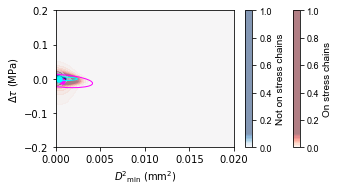

In [8]:
fig = plt.figure(figsize=(5,2.52))
ax = fig.add_subplot()
plt.rc('font', family = 'Arial')
plt.rcParams['font.size'] = 9

plt.contourf(X1_, Y1_, Z1_/Z1_.max(), \
             levels = 100, cmap = 'Reds', alpha = 0.5, vmin = 0, vmax = 0.1)
cb = plt.colorbar()
cb.set_label(label = 'On stress chains', fontsize = 10)
cb.set_ticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
plt.contourf(X2_, Y2_, Z2_/Z2_.max(), \
             levels = 100, cmap = 'Blues', alpha = 0.5, vmin = 0, vmax = 0.1)
cb = plt.colorbar()
cb.set_label(label = 'Not on stress chains', fontsize = 10)
cb.set_ticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
plt.ylabel(r'$\Delta\tau$' + ' (MPa)', fontsize = 10)
plt.xlabel('$\\mathit{D}$'+ '$^\\mathrm{2}$' + '$_\\mathrm{min}$' + ' ' + '(mm$^\\mathrm{2}$)', fontsize = 10)

#  plt the ellipse
plt.scatter(c1_[0], c1_[1], color = 'magenta', s = 30, )
plt.scatter(c2_[0], c2_[1], color = 'cyan', s = 30, )
Ellipse1_ = Ellipse(xy=c1_, width=a1_, height=b1_, \
                    angle=math.degrees(math.atan(direction_a1_[1] / direction_a1_[0])), \
                   fill = None, edgecolor = 'magenta', linewidth = 1)
ax.add_patch(Ellipse1_)

Ellipse2_ = Ellipse(xy=c2_, width=a2_, height=b2_, \
                    angle=math.degrees(math.atan(direction_a2_[1] / direction_a2_[0])), \
                   fill = None, edgecolor = 'cyan', linewidth = 1)
ax.add_patch(Ellipse2_)

plt.xlim([xmin1_, xmax1_])
plt.ylim([ymin1_, ymax1_])

plt.savefig('notebook_plot/NonaffineVsStress_inSlip.svg', dpi=600, format='svg')
plt.show()

In [9]:
# extract the vectors to plot (high nonaffine on and not on stress chain)
stress_change_HighNonaffine_on_chains_ = []
D2min_HighNonaffine_on_chains_ = []
stress_change_HighNonaffine_not_on_chains_ = []
D2min_HighNonaffine_not_on_chains_ = []

for i_ in range(D2min_4G_.shape[0]):
    if markers_HighNonaffine_4G_[i_] == 1:
        if markers_StressChain_4G_[i_] == 1:  
            stress_change_HighNonaffine_on_chains_.append(stress_change_4G_[i_])
            D2min_HighNonaffine_on_chains_.append(D2min_4G_[i_])   

        else:
            stress_change_HighNonaffine_not_on_chains_.append(stress_change_4G_[i_])
            D2min_HighNonaffine_not_on_chains_.append(D2min_4G_[i_])   

stress_change_HighNonaffine_on_chains_ = np.array(stress_change_HighNonaffine_on_chains_)
D2min_HighNonaffine_on_chains_ = np.array(D2min_HighNonaffine_on_chains_)
stress_change_HighNonaffine_not_on_chains_ = np.array(stress_change_HighNonaffine_not_on_chains_)
D2min_HighNonaffine_not_on_chains_ = np.array(D2min_HighNonaffine_not_on_chains_)

In [10]:
#  kernel-density estimate
xmin1_ = 0.0
xmax1_ = 0.02
ymin1_ = -0.2
ymax1_ = 0.2

xmin2_ = 0.0
xmax2_ = 0.02
ymin2_ = -0.2
ymax2_ = 0.2

v11_ = D2min_HighNonaffine_on_chains_
v12_ = stress_change_HighNonaffine_on_chains_
v21_ = D2min_HighNonaffine_not_on_chains_
v22_ = stress_change_HighNonaffine_not_on_chains_

X1_, Y1_ = np.mgrid[xmin1_:xmax1_:100j, ymin1_:ymax1_:100j]
positions1D_1_ = np.vstack([X1_.ravel(), Y1_.ravel()])
values1_ = np.vstack([v11_, v12_])
kernel_1_ = stats.gaussian_kde(values1_)
Z1_ = np.reshape(kernel_1_(positions1D_1_).T, X1_.shape)


X2_, Y2_ = np.mgrid[xmin2_:xmax2_:100j, ymin2_:ymax2_:100j]
positions1D_2_ = np.vstack([X2_.ravel(), Y2_.ravel()])
values2_ = np.vstack([v21_, v22_])
kernel_2_ = stats.gaussian_kde(values2_)
Z2_ = np.reshape(kernel_2_(positions1D_2_).T, X2_.shape)

In [11]:
#%%  Parameters of confidence ellipse
v11_ = D2min_HighNonaffine_on_chains_
v12_ = stress_change_HighNonaffine_on_chains_
v21_ = D2min_HighNonaffine_not_on_chains_
v22_ = stress_change_HighNonaffine_not_on_chains_
# Covariance matrix and maximum direction
values1_ = np.vstack([v11_, v12_])
cov1_ = np.cov(values1_)
eigenvalues1_, eigenvectors1_ = np.linalg.eig(cov1_)
direction_a1_ = eigenvectors1_[:, np.argmax(eigenvalues1_)]
direction_b1_ = eigenvectors1_[:, np.argmin(eigenvalues1_)]

values2_ = np.vstack([v21_, v22_])
cov2_ = np.cov(values2_)
eigenvalues2_, eigenvectors2_ = np.linalg.eig(cov2_)
direction_a2_ = eigenvectors2_[:, np.argmax(eigenvalues2_)]
direction_b2_ = eigenvectors2_[:, np.argmin(eigenvalues2_)]


# The major and minor axes of an ellipse
v_a1_ = v11_ * direction_a1_[0] + v12_ * direction_a1_[1]
a1_ =  np.std(v_a1_)
v_b1_ = v11_ * direction_b1_[0] + v12_ * direction_b1_[1]
b1_ =  np.std(v_b1_)
v_a2_ = v21_ * direction_a2_[0] + v22_ * direction_a2_[1]
a2_ =  np.std(v_a2_)
v_b2_ = v21_ * direction_b2_[0] + v22_ * direction_b2_[1]
b2_ =  np.std(v_b2_)

# Centroid of ellipse
c1_ = np.array([np.mean(v11_), np.mean(v12_)])
c2_ = np.array([np.mean(v21_), np.mean(v22_)])


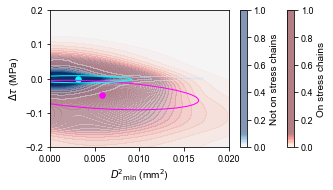

In [12]:
fig = plt.figure(figsize=(5,2.52))
ax = fig.add_subplot()
plt.rc('font', family = 'Arial')
plt.rcParams['font.size'] = 9

plt.contourf(X1_, Y1_, Z1_/Z1_.max(), \
             levels = 100, cmap = 'Reds', alpha = 0.5, vmin = 0, vmax = 0.1)
cb = plt.colorbar()
cb.set_label(label = 'On stress chains', fontsize = 10)
cb.set_ticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
plt.contourf(X2_, Y2_, Z2_/Z2_.max(), \
             levels = 100, cmap = 'Blues', alpha = 0.5, vmin = 0, vmax = 0.1)
cb = plt.colorbar()
cb.set_label(label = 'Not on stress chains', fontsize = 10)
cb.set_ticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
plt.ylabel(r'$\Delta\tau$' + ' (MPa)', fontsize = 10)
plt.xlabel('$\\mathit{D}$'+ '$^\\mathrm{2}$' + '$_\\mathrm{min}$' + ' ' + '(mm$^\\mathrm{2}$)', fontsize = 10)

#  plt the ellipse
plt.scatter(c1_[0], c1_[1], color = 'magenta', s = 30, )
plt.scatter(c2_[0], c2_[1], color = 'cyan', s = 30, )
Ellipse1_ = Ellipse(xy=c1_, width=a1_, height=b1_, \
                    angle=math.degrees(math.atan(direction_a1_[1] / direction_a1_[0])), \
                   fill = None, edgecolor = 'magenta', linewidth = 1)
ax.add_patch(Ellipse1_)

Ellipse2_ = Ellipse(xy=c2_, width=a2_, height=b2_, \
                    angle=math.degrees(math.atan(direction_a2_[1] / direction_a2_[0])), \
                   fill = None, edgecolor = 'cyan', linewidth = 1)
ax.add_patch(Ellipse2_)

plt.xlim([xmin1_, xmax1_])
plt.ylim([ymin1_, ymax1_])

plt.savefig('notebook_plot/NonaffineVsStress_HighNonaffine_inSlip.svg', dpi=600, format='svg')
plt.show()

In [13]:
Ellipse(xy=c1_, width=a1_, height=b1_, angle=0)